# Export Performance Analytics Using Python

# Objective:

## This project focuses on analyzing India’s export trade statistics using Python to identify export trends, high-performing commodities, top destination countries, and regional trade patterns. The dataset contains real-world international trade records including export values, quantities, commodity classifications, and geographic information. Through data cleaning, exploratory data analysis, and visualization techniques, the project aims to generate meaningful business and economic insights from India’s global export activities.

# Dataset Information:
<div style="font-size:14px; line-height:1.4;">
Source : https://indiadataportal.com/p/export-trade-statistics/r/mci-tradestat_export_lfy-cn-mn-eur?utm_source=chatgpt.com  

The dataset is sourced from:

India Data Portal
Trade/export records published through Indian government statistical systems.

This is a government/public economic dataset, which makes your project look more authentic and professional compared to random practice datasets.



The dataset represents:

Exports from India

To multiple countries in europe

It includes:

countries
region
sub-regions
country codes
Example geographic dimensions:

Europe




This allows:

global trade analysis
region-wise export trends
country-level performance analysis

 Timeline - 2024 - 2025
 </div>

# Business Problem
<div style="font-size:14px; line-height:1.4;">

 India exports thousands of commodities to multiple countries and regions worldwide.
 However, identifying:

 top-performing export commodities

high-value export destinations

 regional trade patterns

export growth trends

 quantity vs revenue relationships is difficult without proper data analysis.

 Organizations and policymakers require insights into export performance to:

 understand international market demand

 identify profitable export sectors

 monitor trade growth
</div


## Expected Outcome

 The project aims to:

Analyze India’s export performance over time

Identify top export destination countries

Determine high-performing commodities

Study regional and sub-regional trade trends

Compare export quantity and export value

Generate meaningful business insights using visualization and EDA techniques

# Dataset Size

Metric	                Value

Number of Rows	      532K

Number of Columns    	15

Dataset Size	~       50.6 MB

In [167]:
# Import required libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.graph_objs import heatmap
import plotly.graph_objects as go

import plotly.io as pio
pio.renderers.default = "colab"

# Display Settings
pd.set_option('display.max_columns', None)

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')



In [168]:
dataset = '/content/drive/MyDrive/DA-ANB13/Python/Main Project/exports-to-european-countries.csv'
export_df_main = pd.read_csv(dataset)
export_df_main['date'] = pd.to_datetime(export_df_main['date'])

export_df = export_df_main[
    (export_df_main['date'].dt.year >= 2024) &
    (export_df_main['date'].dt.year <= 2025)
]
export_df.shape

(532491, 15)

In [169]:
print(export_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 532491 entries, 2294980 to 2827470
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   id               532491 non-null  int64         
 1   date             532491 non-null  datetime64[ns]
 2   country_name     532491 non-null  object        
 3   alpha_3_code     530299 non-null  object        
 4   country_code     530299 non-null  float64       
 5   region           532491 non-null  object        
 6   region_code      532491 non-null  int64         
 7   sub_region       532491 non-null  object        
 8   sub_region_code  532491 non-null  int64         
 9   hs_code          532491 non-null  int64         
 10  commodity        532491 non-null  object        
 11  unit             532466 non-null  object        
 12  value_qt         532491 non-null  float64       
 13  value_rs         532491 non-null  float64       
 14  value_dl         5

In [170]:
# Dataset column information
export_df.columns

Index(['id', 'date', 'country_name', 'alpha_3_code', 'country_code', 'region',
       'region_code', 'sub_region', 'sub_region_code', 'hs_code', 'commodity',
       'unit', 'value_qt', 'value_rs', 'value_dl'],
      dtype='object')

In [171]:
# Colummn data types in dataset

print(export_df.dtypes)

id                          int64
date               datetime64[ns]
country_name               object
alpha_3_code               object
country_code              float64
region                     object
region_code                 int64
sub_region                 object
sub_region_code             int64
hs_code                     int64
commodity                  object
unit                       object
value_qt                  float64
value_rs                  float64
value_dl                  float64
dtype: object


# Initial Exploratory Data Analysis (EDA)

In [172]:
# first few rows of the dataset
export_df.head()

,id,date,country_name,alpha_3_code,country_code,region,region_code,sub_region,sub_region_code,hs_code,commodity,unit,value_qt,value_rs,value_dl
2294980,2294980,2024-04-01,Albania,ALB,8.0,Europe,150,Southern Europe,39,3061730,Indian White Shrimp (Fenneropenaeus Indicus),Kgs,17680.0,0.86,0.10
2294981,2294981,2024-04-01,Albania,ALB,8.0,Europe,150,Southern Europe,39,3061750,Flower Shrimp (Penaeus Semisulcatus),Kgs,1630.0,0.10,0.01
2294982,2294982,2024-04-01,Albania,ALB,8.0,Europe,150,Southern Europe,39,3061790,Other Shrimps And Prawns,Kgs,140.0,0.01,0.00
2294983,2294983,2024-04-01,Albania,ALB,8.0,Europe,150,Southern Europe,39,7122000,Onions Dried,Kgs,14140.0,0.19,0.02
2294984,2294984,2024-04-01,Albania,ALB,8.0,Europe,150,Southern Europe,39,9011139,Coffee Rob Parchment Other Grade,Kgs,19200.0,0.72,0.09


In [173]:
# Last few rows of the dataset
export_df.tail()

,id,date,country_name,alpha_3_code,country_code,region,region_code,sub_region,sub_region_code,hs_code,commodity,unit,value_qt,value_rs,value_dl
2827466,2827466,2025-07-01,Ukraine,UKR,804.0,Europe,150,Eastern Europe,151,95030020,Non-Electronic Toys Etc.,Nos,7500.0,0.16,0.02
2827467,2827467,2025-07-01,Ukraine,UKR,804.0,Europe,150,Eastern Europe,151,95069990,Other Sports Equipments,Nos,100.0,0.00,0.00
2827468,2827468,2025-07-01,Ukraine,UKR,804.0,Europe,150,Eastern Europe,151,96081099,Other Ball-Point Pens Without Liquid Ink (For ...,Nos,165120.0,0.11,0.01
2827469,2827469,2025-07-01,Ukraine,UKR,804.0,Europe,150,Eastern Europe,151,96110000,Date;Sealng/Numbrng Stmps(Incl Dvcs Fr Prntg/E...,Kgs,77.0,0.00,0.00
2827470,2827470,2025-07-01,Holy See(Vatican City),VAT,336.0,Europe,150,Southern Europe,39,12093000,Seeds Of Herbaceus Plnts Cultvtd For Flwrs,Kgs,4308.0,0.58,0.07


In [174]:
# Statistical Summary
export_df.describe()

,id,date,country_code,region_code,sub_region_code,hs_code,value_qt,value_rs,value_dl
count,5.324910e+05,532491,530299.000000,532491.0,532491.000000,5.324910e+05,5.324910e+05,532491.000000,532491.000000
mean,2.561225e+06,2024-11-17 14:09:04.085815552,475.571674,150.0,126.929657,5.819001e+07,1.231187e+05,2.065854,0.243242
min,2.294980e+06,2024-04-01 00:00:00,8.000000,150.0,39.000000,2.013000e+06,0.000000e+00,0.000000,0.000000
25%,2.428102e+06,2024-08-01 00:00:00,276.000000,150.0,151.000000,3.406001e+07,5.200000e+01,0.020000,0.000000
50%,2.561225e+06,2024-12-01 00:00:00,528.000000,150.0,154.000000,6.204529e+07,9.900000e+02,0.130000,0.020000
75%,2.694348e+06,2025-04-01 00:00:00,705.000000,150.0,155.000000,8.414901e+07,1.273150e+04,0.710000,0.080000
max,2.827470e+06,2025-07-01 00:00:00,832.000000,150.0,155.000000,9.993009e+07,1.773580e+09,10934.460000,1311.200000
std,1.537171e+05,NaN,240.993660,0.0,48.520641,2.504278e+07,7.084844e+06,45.400816,5.377404


In [175]:
# Null Value Check
print(export_df.isnull().sum())

id                    0
date                  0
country_name          0
alpha_3_code       2192
country_code       2192
region                0
region_code           0
sub_region            0
sub_region_code       0
hs_code               0
commodity             0
unit                 25
value_qt              0
value_rs              0
value_dl              0
dtype: int64


In [176]:
# Duplicate Value Check
export_df.duplicated().sum()

np.int64(0)

In [177]:
# Unique Values in Important Columns
print(f'Countries : {export_df['country_name'].nunique()}')

print(f'Commodities : {export_df['commodity'].nunique()}')

print(f'Region : {export_df['region'].nunique()}')

Countries : 49
Commodities : 8051
Region : 1


## Initial Observations from EDA
* Dataset contains over 532K export trade records

* Export transactions cover multiple European countries and regions

* Dataset includes both quantity (value_qt) and monetary export values (value_rs, value_dl)

* Missing values are minimal and mainly present in country code-related columns

* Time-series analysis is possible using the date column

* Country-wise, commodity-wise, and regional-level analysis can be performed

* Dataset is suitable for business analytics, statistical analysis, and data  visualization tasks

## 1. Check Duplicate Records

In [178]:
export_df.duplicated().sum()

np.int64(0)

Duplicate check was performed using df.duplicated().sum() and no duplicate records were found in the dataset.

## 2. Missing Value Analysis

In [179]:
print(export_df.isnull().sum())

id                    0
date                  0
country_name          0
alpha_3_code       2192
country_code       2192
region                0
region_code           0
sub_region            0
sub_region_code       0
hs_code               0
commodity             0
unit                 25
value_qt              0
value_rs              0
value_dl              0
dtype: int64


In [180]:
# Calculating the percentage of missing value with actual dataset size
print((export_df.isnull().sum() / len(export_df)) * 100)

id                 0.000000
date               0.000000
country_name       0.000000
alpha_3_code       0.411650
country_code       0.411650
region             0.000000
region_code        0.000000
sub_region         0.000000
sub_region_code    0.000000
hs_code            0.000000
commodity          0.000000
unit               0.004695
value_qt           0.000000
value_rs           0.000000
value_dl           0.000000
dtype: float64


In [181]:
# analysing  values in value_qt column
print(export_df['value_qt'].describe())

count    5.324910e+05
mean     1.231187e+05
std      7.084844e+06
min      0.000000e+00
25%      5.200000e+01
50%      9.900000e+02
75%      1.273150e+04
max      1.773580e+09
Name: value_qt, dtype: float64


In [182]:
# Analysing value_dl column with statistical info
print(export_df['value_dl'].describe())

count    532491.000000
mean          0.243242
std           5.377404
min           0.000000
25%           0.000000
50%           0.020000
75%           0.080000
max        1311.200000
Name: value_dl, dtype: float64


In [183]:
# Analysing unit column
print(export_df['unit'].value_counts(dropna=False))

unit
Kgs    329947
Nos    160479
Sqm     24169
Prs      7108
Ctm      3553
Mtr      3151
Kg       1073
Ton      1015
Ltr       909
Crt       470
"         288
Cbm       207
Mts        56
Thd        40
NaN        25
Gif         1
Name: count, dtype: int64


In [184]:
# From the observation of the value count including NaN values, the missing value is 0.13%
# dropping rows will cause uneccessary data loss. Imputing with mode value will create
# incorrect business meaning,like. commodites meausred in litres suddenly changing to kilograms.
# so iam imputing this column with "Unknown" so that no data will be lost.

export_df['unit'] = export_df['unit'].fillna('Unknown')
print(f'After imputing unit column: {export_df['unit'].isnull().sum()}')

After imputing unit column: 0


In [185]:
# Analysing alpha_3_code and country_code columns
print(export_df[['alpha_3_code','country_code']].value_counts(dropna=False))
# mising values in these columns wont affect the analysis because it already has country name
# missing percentage is tiny, business analysis do not depend on these codes.
# so no unecessary manipulation needed. so moving on to column optimization

alpha_3_code  country_code
GBR           826.0           55728
DEU           276.0           49012
NLD           528.0           39129
ITA           380.0           38505
FRA           250.0           36775
ESP           724.0           32625
RUS           643.0           30956
BEL           56.0            25724
POL           616.0           23953
SWE           752.0           16088
CHE           756.0           16073
DNK           208.0           14110
GRC           300.0           13815
IRL           372.0           12402
PRT           620.0           11926
ROU           642.0           11488
CZE           203.0           11352
AUT           40.0             9770
HUN           348.0            8275
NOR           578.0            7992
SVN           705.0            7914
FIN           246.0            7130
HRV           191.0            6059
BGR           100.0            5482
LTU           440.0            4793
SRB           688.0            4662
SVK           703.0            4388
U

In [186]:
#Based on the observation dropping these columns alpha_3_code  and country_code wont affect the analysis
export_df = export_df.drop(columns=['alpha_3_code','country_code'], errors='ignore')

print(f'Rechecking the dataset for null values :\n {export_df.isnull().sum()}')

Rechecking the dataset for null values :
 id                 0
date               0
country_name       0
region             0
region_code        0
sub_region         0
sub_region_code    0
hs_code            0
commodity          0
unit               0
value_qt           0
value_rs           0
value_dl           0
dtype: int64


In [187]:
# Checking the column's datatypes
print(export_df.dtypes)

id                          int64
date               datetime64[ns]
country_name               object
region                     object
region_code                 int64
sub_region                 object
sub_region_code             int64
hs_code                     int64
commodity                  object
unit                       object
value_qt                  float64
value_rs                  float64
value_dl                  float64
dtype: object


In [188]:
from ast import expr_context
# Converting region_code and sub_region_code to objects because they are more of labels for identification
# not used for any mathematical caluculation or analytical purpose

export_df['region_code'] = export_df['region_code'].astype('object')
export_df['sub_region_code'] = export_df['sub_region_code'].astype('object')

In [189]:
export_df[['region_code','sub_region_code']].dtypes

,0
region_code,object
sub_region_code,object


# Data Transformation / Data Wrangling

In [190]:
# Extracting time based features / columns from the date column
# Year column

export_df['year'] = export_df['date'].dt.year
print(export_df['year'].value_counts())

# By extracting this column , 1.yearly trend analysis, 2. yearly export comparison, 3.grouth analysis, can be possible

# from this observation the data is not spread evenly across years

year
2024    295119
2025    237372
Name: count, dtype: int64


In [191]:
# Extracting month column
export_df['month'] = export_df['date'].dt.month
export_df['month_name'] = export_df['date'].dt.month_name()
print(export_df['month_name'].value_counts())

# from the observation export activities varies across months
# Hightest
# February, March, Aril
# Lowest
# October, July
# This can be useful to analyse,
# 1. Possible financial year effects
# 2. seasonal trade behavior
# 3. export cycle patterns

month_name
May          68909
July         67175
June         67058
April        66116
March        35472
October      33560
December     32959
January      32674
August       32428
February     32334
September    32308
November     31498
Name: count, dtype: int64


In [192]:
# Quarterly data extraction
export_df['quarter'] = export_df['date'].dt.quarter
print(export_df['quarter'].value_counts())

quarter
2    202083
3    131911
1    100480
4     98017
Name: count, dtype: int64


## Final Exploratory Data Analysis(EDA)

In [193]:
# Re-checking dataset shape
print(export_df.shape)

(532491, 17)


In [194]:
print(export_df.columns)

Index(['id', 'date', 'country_name', 'region', 'region_code', 'sub_region',
       'sub_region_code', 'hs_code', 'commodity', 'unit', 'value_qt',
       'value_rs', 'value_dl', 'year', 'month', 'month_name', 'quarter'],
      dtype='object')


In [195]:
# Re-checking for null values
print(export_df.isnull().sum())

id                 0
date               0
country_name       0
region             0
region_code        0
sub_region         0
sub_region_code    0
hs_code            0
commodity          0
unit               0
value_qt           0
value_rs           0
value_dl           0
year               0
month              0
month_name         0
quarter            0
dtype: int64


# Stage 3
# Statistical analysis & Visualizations**

In [196]:

# Measure of central tendency will be calculated ono these meaningful numerical columns
# 1. value_qt [ export quantity]
# 2. value_rs [export values indian rupees]

In [197]:
# 1. value_qt

#print(export_df['value_qt'].describe())

# The export quantity is positively skewed,however interpretation should ne done carefully,
# because the dataset has multple units [kgs,prs,litres,square meter] within same column.

# Identitifying dominant unit
# quantity analysis for kilograms.

kgs_data = export_df[export_df['unit'] == 'Kgs']
print(f'After creating separte data frame for unit kgs :\n {kgs_data.shape}')


After creating separte data frame for unit kgs :
 (329947, 17)


## Since export quantities are recorded using multiple commodity-specific units, quantity-based statistical interpretations should be performed cautiously and preferably within individual unit categories.

In [198]:
kgs_data.describe()

# quantity statistics were mixed across incompatible units.

# Now - quantity analysis is performed with standardized uit category(KGs), making the statistical interpretation more easier



,id,date,hs_code,value_qt,value_rs,value_dl,year,month,quarter
count,3.299470e+05,329947,3.299470e+05,3.299470e+05,329947.000000,329947.000000,329947.000000,329947.000000,329947.000000
mean,2.562056e+06,2024-11-18 09:22:17.287503360,4.921613e+07,1.633150e+05,2.131744,0.251049,2024.448445,6.216244,2.425383
min,2.294980e+06,2024-04-01 00:00:00,2.013000e+06,0.000000e+00,0.000000,0.000000,2024.000000,1.000000,1.000000
25%,2.429120e+06,2024-08-01 00:00:00,2.933799e+07,7.500000e+01,0.020000,0.000000,2024.000000,4.000000,2.000000
50%,2.562726e+06,2024-12-01 00:00:00,4.016931e+07,1.250000e+03,0.150000,0.020000,2024.000000,6.000000,2.000000
75%,2.694800e+06,2025-04-01 00:00:00,7.307939e+07,1.706800e+04,0.780000,0.090000,2025.000000,8.000000,3.000000
max,2.827470e+06,2025-07-01 00:00:00,9.806000e+07,1.773580e+09,10934.460000,1311.200000,2025.000000,12.000000,4.000000
std,1.536893e+05,NaN,2.544853e+07,8.984973e+06,53.803727,6.373984,0.497336,3.052436,0.995476


### Measure of central tendency

In [199]:
# value_qt distribution
print(f'value_qt distribution :\n{kgs_data['value_qt'].agg(['mean','median'])}\n')
limit_qt = kgs_data['value_qt'].quantile(0.95)


# Value_rs distribution
print(f'value_rs distribution :\n{kgs_data['value_rs'].agg(['mean','median'])}')

#Removing extreme outliers temporarly for visualization
limit_rs = kgs_data['value_rs'].quantile(0.95)

value_qt distribution :
mean      163314.973187
median      1250.000000
Name: value_qt, dtype: float64

value_rs distribution :
mean      2.131744
median    0.150000
Name: value_rs, dtype: float64


Text(0, 0.5, 'Frequency')

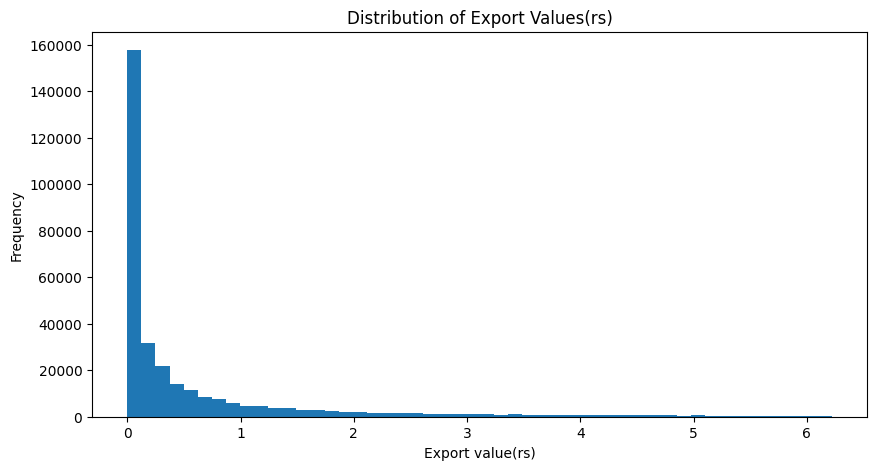

In [200]:
# Value_rs visualizing distribution

plt.figure(figsize=(10,5))
plt.hist(
    kgs_data[kgs_data['value_rs'] < limit_rs]['value_rs'],
    bins=50
)

plt.title('Distribution of Export Values(rs)')
plt.xlabel('Export value(rs)')
plt.ylabel('Frequency')


### Iterpretation of Histogram — value_rs
* Most of export transactions are concentrated at lower export values near(0-1).

* As the export values increases the frequency of transaction decreases rapidly,

* Only a small number of transactions have higher export value.

* The histogram shows long right tail, indicating positiviely skewed distribution.

* This suggest a few high-value transctions contribute to overall export trade.

In [201]:
# Variance and standard deviation of value_rs
print(f'Stadand deviation and variance :\n{kgs_data['value_rs'].agg(['var','std'])}')


Stadand deviation and variance :
var    2894.840990
std      53.803727
Name: value_rs, dtype: float64


### Interpretation — Variance and Standard Deviation (value_rs)
* The standard deviation (53.80) is very high when compared to mean(2.13).

* This indicates export values are widely spread across the dataset.

* The variance 2894.84 also confirms huge variability in export values.

* The extremely high value transactions increases the spread significally.

* This shows the export trade values are not uniformly distributed across commodities and transactions

## Skewness and Kurtosis

Skewness and kutosis for value_rs:
 skew      124.618385
kurt    18567.074385
Name: value_rs, dtype: float64



Text(0, 0.5, 'value_rs')

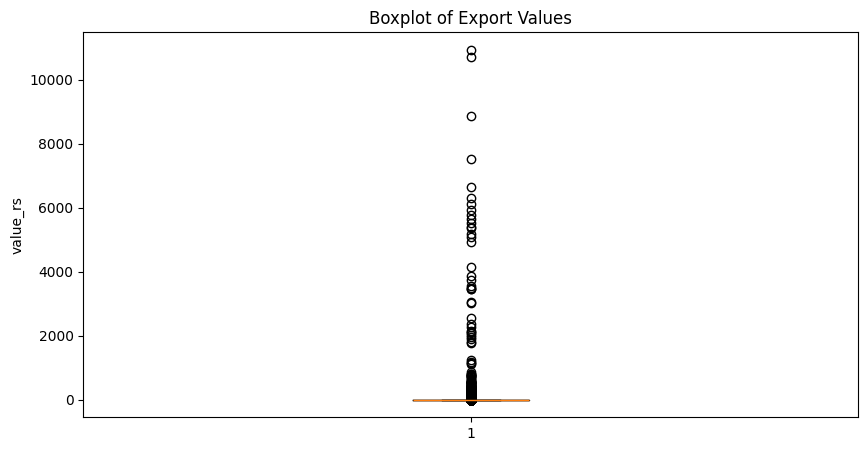

In [202]:
print(f'Skewness and kutosis for value_rs:\n {kgs_data['value_rs'].agg(['skew','kurt'])}\n')

plt.figure(figsize=(10,5))
plt.boxplot(kgs_data['value_rs'])
plt.title('Boxplot of Export Values')
plt.ylabel('value_rs')

### Interpretation of Boxplot — value_rs
* The box plot shows large number of outliers abover the upper whisker.

* Most export values are concentrated near the lower range of the dataset.

* The distribution is highly positively skewed, which matches the skewness and kurtosis results.

* The presence of many outliers indicates high variability in export values across transactions.

## Supporting aggreagted values for analysis

In [203]:
# Country wise analysis

# 1. top countries by trade value(rs)
top_countries_trade_value = kgs_data.groupby('country_name')['value_rs'].sum().sort_values(ascending=False)[:10]
print(top_countries_trade_value)

# 2.country wise commodity diversity
country_commodity_diversity = kgs_data.groupby('country_name')['commodity'].nunique().sort_values(ascending=False)[:10]
#print(country_commodity_diversity)

# 3.Quantity trade by country
quantity_trade_country = kgs_data.groupby('country_name')['value_qt'].sum().sort_values(ascending= False)[:10]
#print(round(quantity_trade_country,2)/ 1e9)


country_name
Kingdom of the Netherlands                              205123.19
United Kingdom of Great Britain and Northern Ireland     92956.96
Germany                                                  69144.38
Italy                                                    53687.76
France                                                   50711.95
Belgium                                                  45090.65
Spain                                                    35251.98
Russian Federation                                       35100.67
Poland                                                   18787.51
Switzerland                                              12944.23
Name: value_rs, dtype: float64


In [204]:
# Commodity analysis

# 1. Top commodity by value(rs)
top_commodity_by_value = kgs_data.groupby('commodity')['value_rs'].sum().sort_values(ascending=False)[:10]
print(round(top_commodity_by_value),2)

# 2.Top commodity by quantity
top_commodity_by_quantity = kgs_data.groupby('commodity')['value_qt'].sum().sort_values(ascending = False)[:10]
#print(round(top_commodity_by_quantity,2)/ 1e9)

# 3. Commodity-wise average price
commodity_avg_price = kgs_data.groupby('commodity')['value_rs'].mean().sort_values(ascending=False)
#print(commodity_avg_price)



commodity
Automotive Diesel Fuel, Not Containing Biodiesel, Conforming To Standard Is 1460    105677.0
Aviation Turbine Fuels, Kerosene Type Conforming To Standard Is 1571                 74076.0
Other                                                                                32857.0
Other Medcne Put Up For Retail Sale N.E.S                                            20136.0
Others                                                                               17830.0
Otr Prtsandaccssrs Of Vhcls Of Hdg 8701-8705                                         10120.0
Vannamei Shrimp (Litopenaeus Vannamei)                                                6372.0
Aluminium Ingots-Not Alloyed                                                          5994.0
Flexible Intermediate Bulk Containers Of Man Made Textile Materials                   5842.0
Of Aeroplanes Helicopters                                                             5140.0
Name: value_rs, dtype: float64 2


In [205]:
# Time series analysis

# 1. Monthly trade trends
monthly_trade = kgs_data.groupby('month_name')['value_rs'].sum()
#print(monthly_trade)

# 2. Yearly trade trends
yearly_trade = kgs_data.groupby('year')['value_rs'].sum().sort_values(ascending = False)
#print(yearly_trade)

# 3. Quarterly performance
quartely_trade = kgs_data.groupby(['year','quarter'])['value_rs'].sum()
print(quartely_trade)



year  quarter
2024  2          148106.14
      3          128861.18
      4          115688.38
2025  1          129035.41
      2          135071.92
      3           46599.62
Name: value_rs, dtype: float64


In [206]:

# Correlation Analysis

correlation_analysis = kgs_data[["value_qt", "value_rs", "value_dl", "year", "month", "quarter"]].corr()
print(correlation_analysis)


          value_qt  value_rs  value_dl      year     month   quarter
value_qt  1.000000  0.987900  0.987547 -0.001064 -0.000831 -0.000729
value_rs  0.987900  1.000000  0.999896 -0.000534 -0.001326 -0.001211
value_dl  0.987547  0.999896  1.000000 -0.001050 -0.001074 -0.000942
year     -0.001064 -0.000534 -0.001050  1.000000 -0.643599 -0.634808
month    -0.000831 -0.001326 -0.001074 -0.643599  1.000000  0.962590
quarter  -0.000729 -0.001211 -0.000942 -0.634808  0.962590  1.000000


## Visualization

### 1. Univariate Analysis

Text(0, 0.5, 'Frequency')

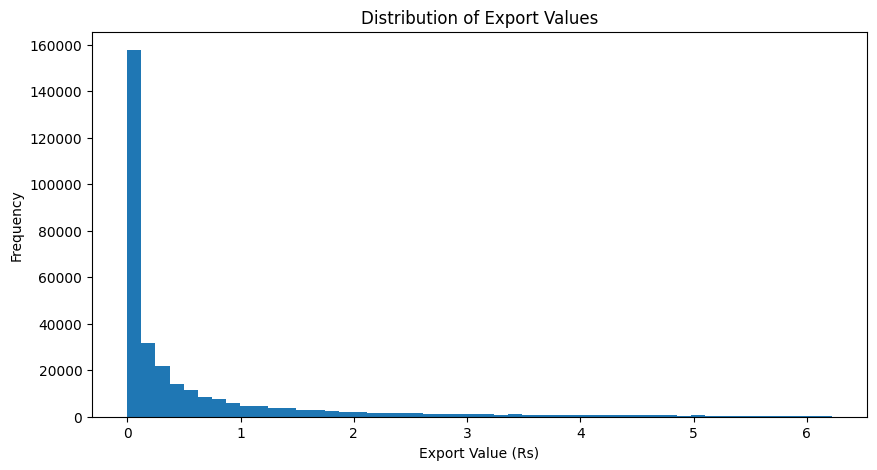

In [207]:
#Histogram of value_rs
limit = kgs_data['value_rs'].quantile(0.95)

plt.figure(figsize=(10,5))
plt.hist(kgs_data[kgs_data['value_rs'] < limit]['value_rs'], bins = 50)
plt.title('Distribution of Export Values')
plt.xlabel('Export Value (Rs)')
plt.ylabel('Frequency')

Interpretation:

* Most export transactions have lower export values.

* As export value increases, the number of transactions decreases.

* Only a few transactions contain very high export values.

* The distribution is positively skewed with a long right tail.

* This shows that export trade value is unevenly distributed across transactions.

Text(0, 0.5, 'value_rs')

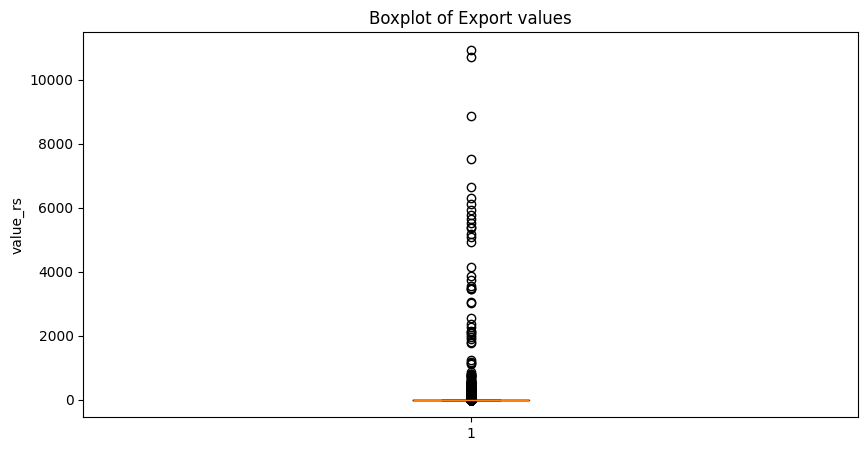

In [208]:
# Boxplot of value_rs - to detect outliers

plt.figure(figsize=(10,5))
plt.boxplot(kgs_data['value_rs'])
plt.title('Boxplot of Export values')
plt.ylabel('value_rs')

### Interpretation:

* The boxplot shows many outliers in the dataset.

* Most export values are concentrated in the lower range.

* A few export transactions have extremely high values compared to the majority of records.

* The distribution is highly positively skewed.

* This indicates that some export shipments contribute disproportionately high export values*

Text(0, 0.5, 'Country')

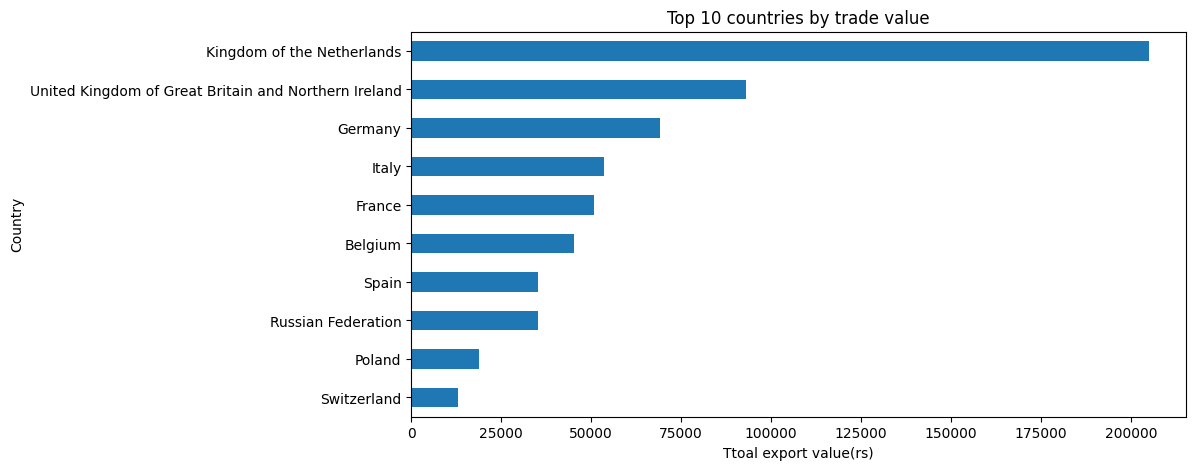

In [209]:
# Top countries with highest trade value

plt.figure(figsize=(10,5))
top_countries_trade_value.sort_values().plot(kind ='barh')
plt.title('Top 10 countries by trade value')
plt.xlabel('Ttoal export value(rs)')
plt.ylabel('Country')


### Interpretation:

* The kingdom of Netherlands has the highest export value.

* The chart highlights major export destinations based on total trade value.

* Export value concentrated among few major european countries.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'January'),
  Text(1, 0, 'February'),
  Text(2, 0, 'March'),
  Text(3, 0, 'April'),
  Text(4, 0, 'May'),
  Text(5, 0, 'June'),
  Text(6, 0, 'July'),
  Text(7, 0, 'August'),
  Text(8, 0, 'September'),
  Text(9, 0, 'October'),
  Text(10, 0, 'November'),
  Text(11, 0, 'December')])

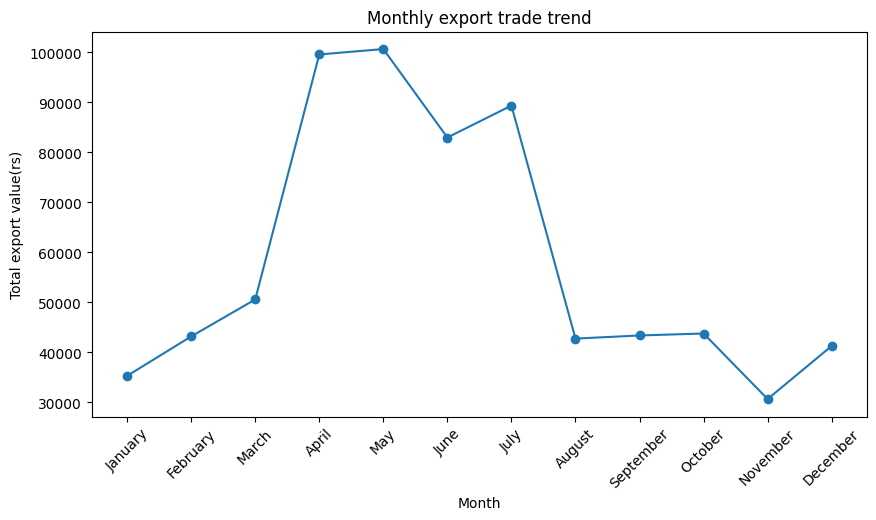

In [210]:
# Monthly Trade trends

month_order = ['January','February','March','April','May','June',
                'July','August','September','October','November','December']

monthly_trade = monthly_trade = kgs_data.groupby('month_name')['value_rs'].sum()
monthly_trade = monthly_trade.reindex(month_order)
#print(monthly_trade)
plt.figure(figsize=(10,5))
plt.plot(monthly_trade.index , monthly_trade.values , marker = 'o')
plt.title('Monthly export trade trend')
plt.xlabel('Month')
plt.ylabel('Total export value(rs)')
plt.xticks(rotation = 45)


### Interpretation for Month trade trends:

 * Export trade values gradually increase from january to may.

 * May hold the highest trade records in the dataset.

 * After july the export trade value decreases and remains relatively stable for most of the months.

 * November shows lowest trade value among all months.

 * The chart indicates seasonal variation in export trade values across different months.

## 2 . Bivariate analysis

Text(0, 0.5, 'Trade value(rs)')

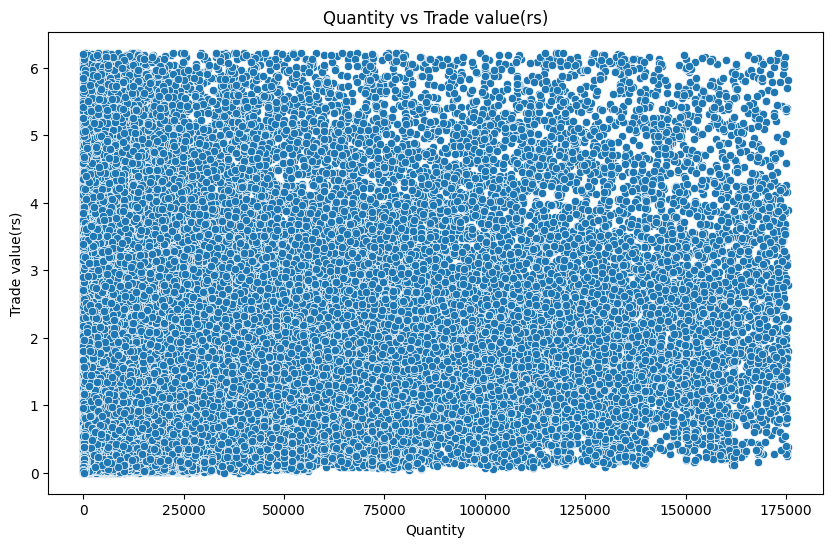

In [211]:
#1. Quantity vs Export Value
limit_rs = kgs_data['value_rs'].quantile(0.95)
limit_qt = kgs_data['value_qt'].quantile(0.95)

filtered_data = kgs_data[ (kgs_data['value_qt'] < limit_qt) &
                         (kgs_data['value_rs'] < limit_rs)]

plt.figure(figsize=(10,6))
sns.scatterplot(data = filtered_data, x= 'value_qt', y = 'value_rs')
plt.title('Quantity vs Trade value(rs)')
plt.xlabel('Quantity')
plt.ylabel('Trade value(rs)')

## Since the dataset is too larges points are overlapping eventhough value_qt and valure_rs have strong positive relationship. Hence plotting with sample datas

Text(0, 0.5, 'Trade value(rs)')

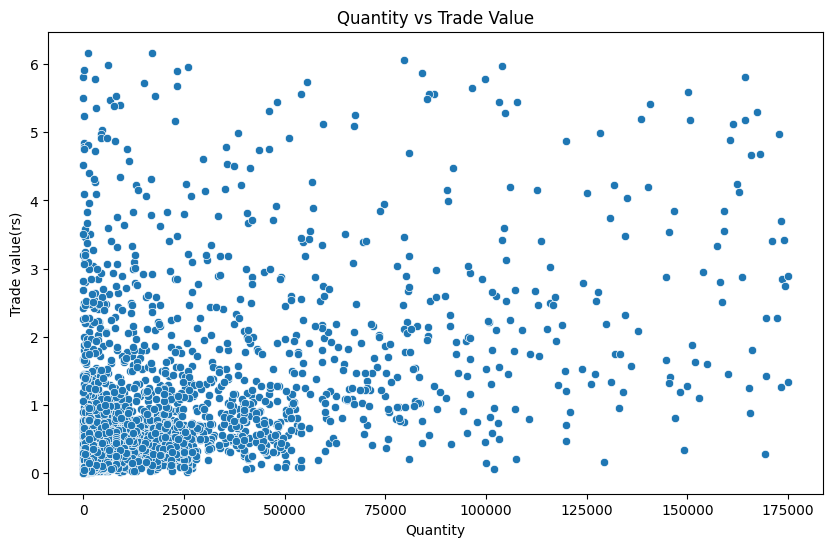

In [212]:
sample_data = filtered_data.sample(5000, random_state=42)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_data,
    x='value_qt',
    y='value_rs'
)

plt.title('Quantity vs Trade Value')
plt.xlabel('Quantity')
plt.ylabel('Trade value(rs)')

### Interpretation

* The scatter plot shows the positive relationship between export quantity and trade value.

* Most export transactions are concentrated at lower export quantity and lower trade value.

* As export quantity increases, trade value also tends to increase.

* A few high quantity transaction are visible, indicating large export shipments.

* The chart suggests that export value is strongly influenced by export quantity.

Text(0.5, 1.0, 'Correlation Analysis')

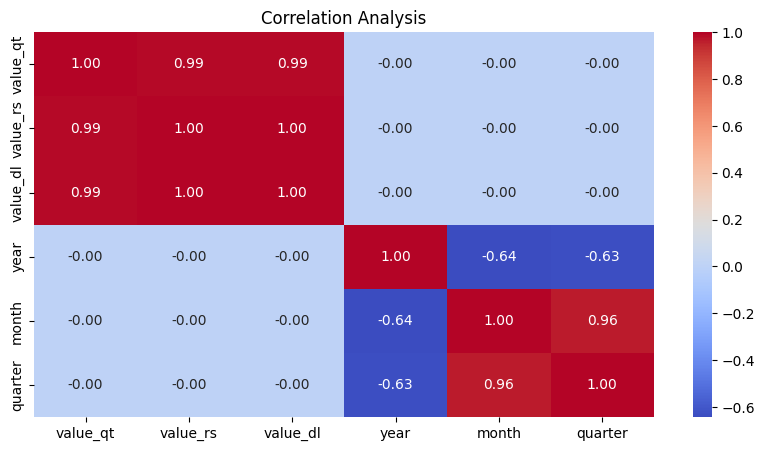

In [213]:
#2. Correlation heatmap

plt.figure(figsize=(10,5))

sns.heatmap(correlation_analysis, annot=True,cmap='coolwarm', fmt='.2f')
plt.title('Correlation Analysis')

### Interpretation:

* Export quantity, trade value rupees and trade value dollars are strongly positively correlated.

* Higher the eport quantity generally increases the export trade value.

* Time-realted variables like year,month shows weak correlation with trade values.

* Month and quarter shows strong correlation because quarters are derived from months.



Text(0, 0.5, 'Country')

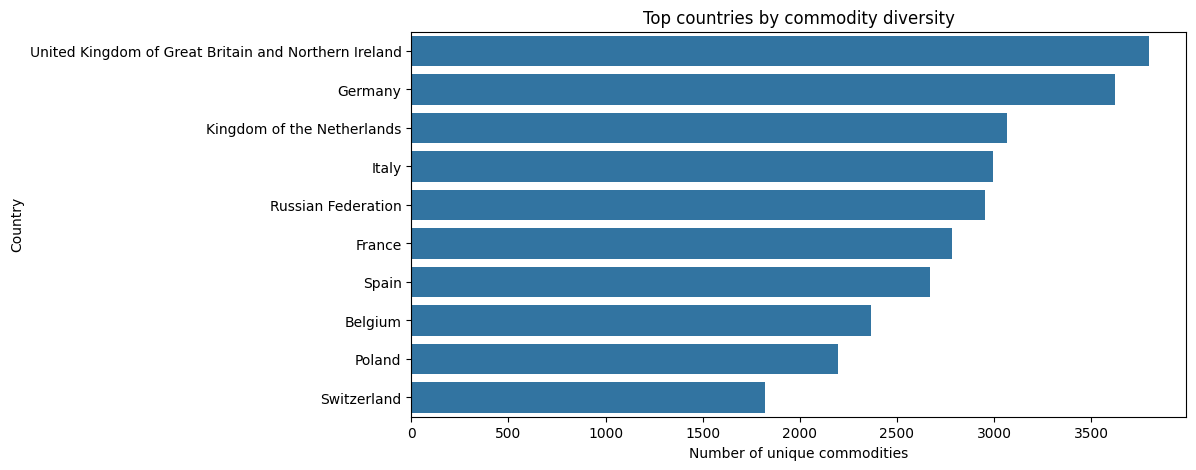

In [214]:
#3. Country vs Commodity Diversity

plt.figure(figsize=(10,5))
sns.barplot(x = country_commodity_diversity.values,
            y = country_commodity_diversity.index)
plt.title('Top countries by commodity diversity')
plt.xlabel('Number of unique commodities')
plt.ylabel('Country')

Interpreatation:

* The United Kingdom has the highest commodity diversity, meaning it trades the widest range of different commodities among the countries shown

* The Netherlands, Italy, and Russia also trade a large variety of commodities, each with around 3,000 or more unique commodity types.

* Switzerland has the lowest commodity diversity in this chart, but it is still among the top 10, so its trade basket is still broad compared with countries outside this list.

* Countries with higher commodity diversity may have more diversified trade relationships and may be less dependent on a small number of products.

* Countries with lower diversity may be more specialized or may have fewer types of commodities recorded in the dataset.

Text(0, 0.5, 'Commodity')

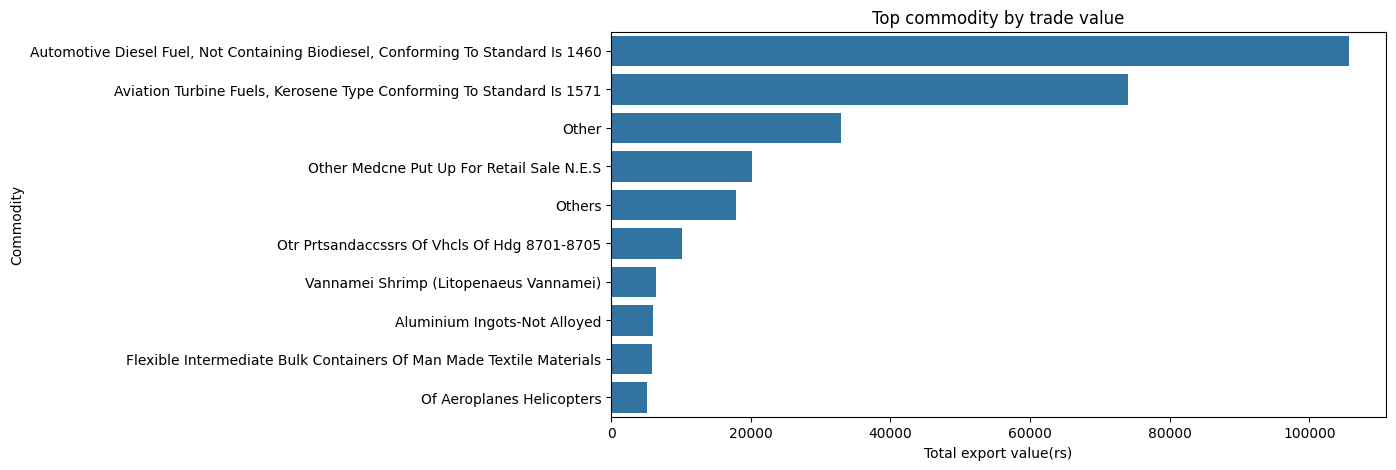

In [215]:
#4. Top Commodities by Trade Value

plt.figure(figsize = (10,5))

sns.barplot( x= top_commodity_by_value.values,
              y = top_commodity_by_value.index)
plt.title('Top commodity by trade value')
plt.xlabel('Total export value(rs)')
plt.ylabel('Commodity')

### Intrepretation:

* Automotive diesel fuel is the highest-value export commodity in this dataset. It contributes much more export value than any other listed commodity.

* The top two commodities are both fuel products, meaning the export value is strongly driven by the energy or petroleum category.

* Items such as vehicle parts, shrimp, aluminium ingots, bulk containers, and aircraft/helicopter-related products contribute smaller export values compared with fuel products.

* The chart suggests that the export basket is not evenly distributed. A small number of commodities account for a major share of total export value.



## Multivariate Analysis

In [216]:
#1. Quarterly Trade Performance by Year

quartely_trade =(kgs_data.groupby(['year','quarter'])['value_rs']
                 .sum().reset_index())
print(quartely_trade.head())
print(quartely_trade.dtypes)
fig = px.line(
    quartely_trade,
    x="quarter",
    y="value_rs",
    color="year",
    width=1200, height=600,
    markers=True,
    title="Quarterly Export Trade Performance by Year",
    labels={
        "quarter": "Quarter",
        "value_rs": "Total Export Value (Rs)",
        "year": "Year"
    }
)
fig.update_xaxes(
    tickmode="array",
    tickvals=[1, 2, 3, 4],
    ticktext=["Q1", "Q2", "Q3", "Q4"]
)
fig.show()

   year  quarter   value_rs
0  2024        2  148106.14
1  2024        3  128861.18
2  2024        4  115688.38
3  2025        1  129035.41
4  2025        2  135071.92
year          int32
quarter       int32
value_rs    float64
dtype: object


Interpretation:

* Q2 is the strongest quarter in both years. Export value reaches its highest point in Q2 for both 2024 and 2025.

* 2024 performs better than 2025 in the comparable quarters Q2 and Q3. In both quarters, the 2024 export value is higher than the 2025 export value.

* The biggest gap between the two years is in Q3. 2024 Q3 is much higher than 2025 Q3, showing a major decline in 2025 during that quarter.

* 2024 has no Q1 value shown, and 2025 has no Q4 value shown. So the year-to-year comparison should be made only for the quarters where data is available.

* Overall, the visual suggests that exports peaked in Q2, but performance weakened afterward, especially in 2025.

In [217]:

#2. 'Country vs Month Export Trade - 2024


top5_countries = (
    kgs_data.groupby('country_name')['value_rs']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)



heatmap_data = kgs_data[
    (kgs_data['country_name'].isin(top5_countries)) &
    (kgs_data['year'] == 2024)
]


country_order = (
    heatmap_data.groupby('country_name')['value_rs']
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)

pivot_table = heatmap_data.pivot_table(
    values='value_rs',
    index='country_name',
    columns='month_name',
    aggfunc='sum'
)
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

existing_months = [
    m for m in month_order if m in pivot_table.columns
]

pivot_table = pivot_table[existing_months]
pivot_table = pivot_table.reindex(country_order)

fig = px.imshow(
    pivot_table,
    text_auto='.0f',
    color_continuous_scale='Viridis',
    title='2024 Country vs Month Export Heatmap',
    aspect='auto'
)

#fig.update_yaxes(autorange='reversed')

fig.update_layout(
    width=1000,
    height=500
)

fig.show()






### Interpretation:

* The Kingdom of the Netherlands has the highest export value in almost every month shown.The Netherlands performs strongest in April and May, with export values around 19k.

* The United Kingdom is the second strongest country in this chart.
The United Kingdom has its highest export value in April, followed by May and October.

* Germany, France, and Italy have much lower export values compared with the Netherlands and the United Kingdom.France performs well in May, but its export value drops sharply in June and remains lower afterward.

* Overall, exports are strongest in the earlier available months, especially April and May, and weaker toward the end of the year.The chart suggests that 2024 export performance is heavily driven by the Netherlands.

In [218]:

#3.  Region + Commodity + Export Value Treemap



# Top 10 commodities by export value
top_commodities = (
    kgs_data.groupby("commodity")["value_rs"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

tree_data = kgs_data[kgs_data["commodity"].isin(top_commodities)].copy()

# Remove missing, zero, or negative values
tree_data = tree_data.dropna(subset=["country_name", "commodity", "value_rs"])
tree_data = tree_data[tree_data["value_rs"] > 0]

grouped_data = (
    tree_data.groupby(["country_name", "commodity"], as_index=False)["value_rs"]
    .sum()
)

# Safety check
#print("Total export value:", grouped_data["value_rs"].sum())
#print(grouped_data.head())

fig = px.treemap(
    grouped_data,
    path=["country_name", "commodity"],
    values="value_rs",
    title="Export Value Contribution by Country and Commodity",
    color="value_rs",
    color_continuous_scale="Blues",
    labels={"value_rs": "Export Value (Rs)"}
)

fig.show()

### Interpretation:

* The Kingdom of the Netherlands contributes the highest export value in this chart..

* Within the Netherlands, automotive diesel fuel is the largest export contributor.Aviation turbine fuel is also a major export commodity for the Netherlands.

* The United Kingdom, France, Belgium, and Germany also contribute to export value, but their shares are much smaller than the Netherlands.

* The chart shows that export value is not evenly distributed across countries.
A few countries and a few commodities contribute most of the total export value.

* From a business point of view, this suggests that exports are highly concentrated in selected countries and selected commodities.

* If fuel-related exports or Netherlands trade decline, the overall export value may be affected significantly.